#### Uključivanje potrebnih biblioteka
- Biblioteka pandas - omogućava nam rad sad dataset-om (mogućnost čitanja, pisanja, modifikacije i sl.)
- Biblioteka numpy - omogućava nam rad sa matematičkim funkcijama, nizovima, listama i sl.
- Bibilioteka matplotlib.pyplot - omogućava nam crtanje grafikona
- Bibilioteka seaborn - omogućava nam detaljnije i naprednije crtanje grafika za analizu

In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Uključivanje dataset-a i njegov opis (Faza 1)
- Link: https://www.kaggle.com/datasets/fedesoriano/air-quality-data-set?resource=download&select=AirQuality.csv
- Opis: 
    - Dataset sadrži podatke dobijene od senzora zagadjenosti vazduha postavljenog u Italijanskom gradu od 2004. do 2005. godine
    - Kolone:
        - Datum (DD/MM/YYYY)
        - Vreme (HH.MM.SS)
        - Tačna jednočasovna prosečna koncentracija CO u mg/m³
        - PT08.S1 (kalaj-oksid) – prosečan jednočasovni odziv senzora (nominalno cilja CO)
        - Tačna jednočasovna prosečna koncentracija nemetanskih ugljovodonika u µg/m³ (referentni analizator)
        - Tačna jednočasovna prosečna koncentracija benzena u µg/m³ (referentni analizator)
        - PT08.S2 (titanijum-dioksid) – prosečan jednočasovni odziv senzora (nominalno cilja NMHC)
        - Tačna jednočasovna prosečna koncentracija NOx u ppb (referentni analizator)
        - PT08.S3 (volfram-oksid) – prosečan jednočasovni odziv senzora (nominalno cilja NOx)
        - Tačna jednočasovna prosečna koncentracija NO₂ u µg/m³ (referentni analizator)
        - PT08.S4 (volfram-oksid) – prosečan jednočasovni odziv senzora (nominalno cilja NO₂)
        - PT08.S5 (indijum-oksid) – prosečan jednočasovni odziv senzora (nominalno cilja O₃)
        - Temperatura u °C
        - Relativna vlažnost vazduha (%)
        - AH – apsolutna vlažnost

- Skup podataka sadrži 9357 instanci sa satnim prosečnim vrednostima odziva niza od 5 metal-oksidnih hemijskih senzora ugrađenih u uređaj za merenje kvaliteta vazduha. Uređaj je bio postavljen na terenu u značajno zagađenom području, na nivou puta, u jednom italijanskom gradu. Podaci su prikupljani od marta 2004. do februara 2005. godine (jedna godina), što predstavlja najduže slobodno dostupno snimanje odziva senzora za kvalitet vazduha postavljenih na terenu.
- Referentne satne prosečne koncentracije za CO, nemetanske ugljovodonike, benzen, ukupne azotne okside (NOx) i azot-dioksid (NO₂) obezbeđene su od strane sertifikovanog analizatora koji je bio postavljen zajedno sa uređajem. U podacima postoje dokazi o unakrsnoj osetljivosti, kao i o „concept drift“ i „sensor drift“ pojavama, što je opisano u radu De Vito i saradnici, Sens. And Act. B, Vol. 129,2,2008 (navod je obavezan), a što eventualno utiče na sposobnosti senzora da precizno procene koncentracije.
- Nedostajuće vrednosti su označene sa vrednošću -200.

In [3]:
df = pd.read_csv('AirQuality.csv', sep=';') # koristimo sep=';' jer su kolone odvojene sa tačka-zarezom

Koristeći funkciju .head(int n) možemo dobiti prvih n redova za dataset-a sa nazivima kolona, kako bi mogli da vidimo primer šta se nalazi u istom.

In [4]:
df.head(10)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,Unnamed: 15,Unnamed: 16
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578",NaN,NaN
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255",NaN,NaN
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502",NaN,NaN
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867",NaN,NaN
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888",NaN,NaN
5,10/03/2004,23.00.00,"1,2",1197.0,38.0,"4,7",750.0,89.0,1337.0,96.0,1393.0,949.0,"11,2","59,2","0,7848",NaN,NaN
6,11/03/2004,00.00.00,"1,2",1185.0,31.0,"3,6",690.0,62.0,1462.0,77.0,1333.0,733.0,"11,3","56,8","0,7603",NaN,NaN
7,11/03/2004,01.00.00,1,1136.0,31.0,"3,3",672.0,62.0,1453.0,76.0,1333.0,730.0,"10,7","60,0","0,7702",NaN,NaN
8,11/03/2004,02.00.00,"0,9",1094.0,24.0,"2,3",609.0,45.0,1579.0,60.0,1276.0,620.0,"10,7","59,7","0,7648",NaN,NaN
9,11/03/2004,03.00.00,"0,6",1010.0,19.0,"1,7",561.0,-200.0,1705.0,-200.0,1235.0,501.0,"10,3","60,2","0,7517",NaN,NaN


Koristeći funkciju .shape, možemo dobiti dimenzije našeg dataset-a (u našem slučaju se one nalaze ispod 9471 red i 17 kolona)

In [5]:
df.shape

(9471, 17)

Koristeći .describe() funkciju možemo da dobijemo neke osnovne statističke podatke vezane za naš dataset

In [6]:
df.describe()

,PT08.S1(CO),NMHC(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),Unnamed: 15,Unnamed: 16
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,0.0,0.0
mean,1048.990061,-159.090093,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032,NaN,NaN
std,329.832710,139.789093,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184,NaN,NaN
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,NaN,NaN
25%,921.000000,-200.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000,NaN,NaN
50%,1053.000000,-200.000000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000,NaN,NaN
75%,1221.000000,-200.000000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000,NaN,NaN
max,2040.000000,1189.000000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,NaN,NaN


Koristeći funkciju .info(), možemo dobiti podatke o tipovima kolona, da li je broj ili objekat (sve ostalo)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   object 
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   object 
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   object 
 13  RH             9357 non-null   object 
 14  AH             9357 non-null   object 
 15  Unnamed: 15    0 non-null      float64
 16  Unnamed: 16    0 non-null      float64
dtypes: float64(10), object(7)
memory usage: 1.2+ MB


# Vizuelizacija podataka i dinamičko predstavljanje (Faza 2)

Za početak prikazujemo distribuciju parametra koji imaju float64 vrednosti, da bi prikazali grafikon kako treba, sklonio sam NaN i -200 vrednosti.
U suprotnom bi nam grafik izgledao dosta drugačije.

In [8]:
float64_cols = df.select_dtypes(include=['float64']).columns

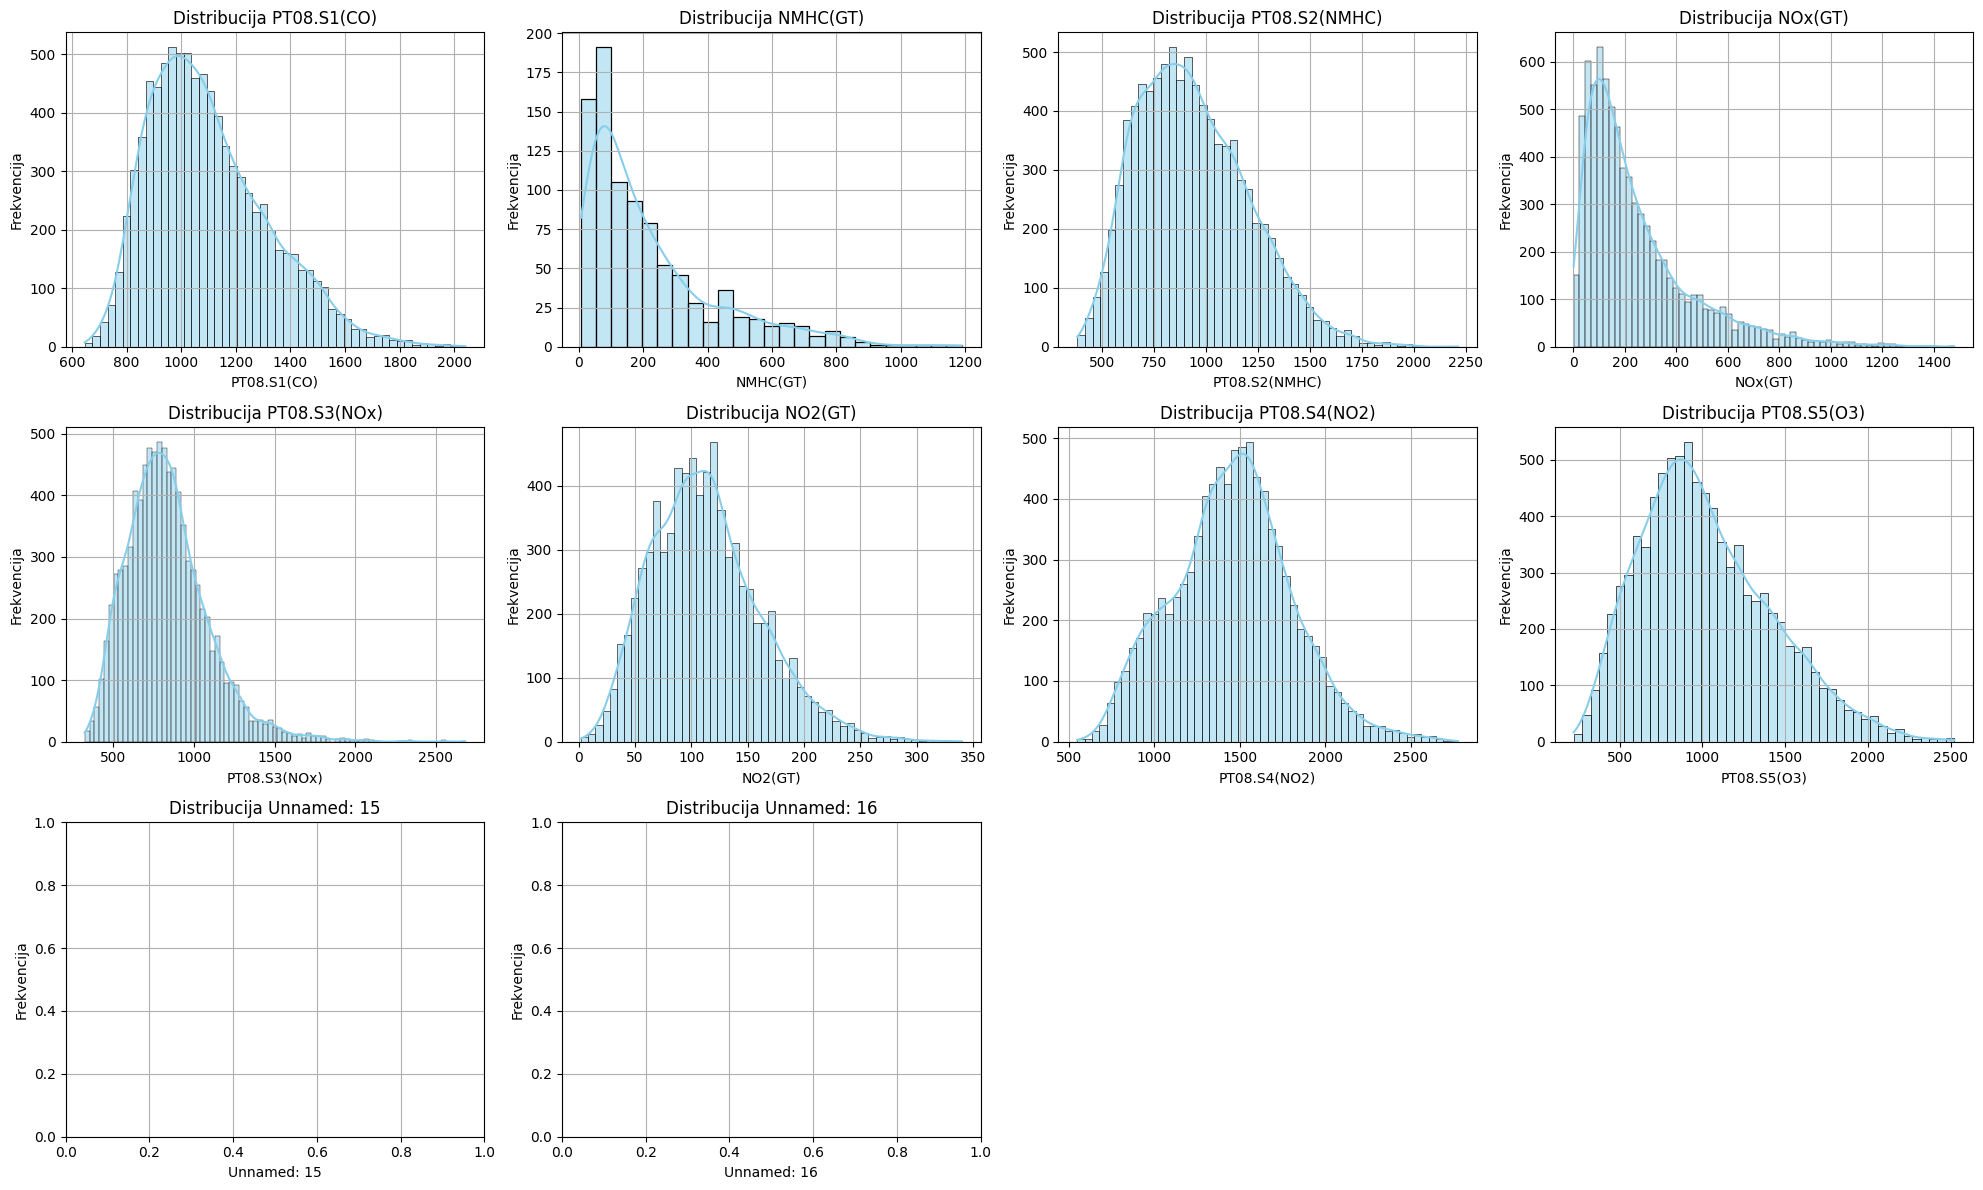

In [9]:
n = len(float64_cols)
cols = 4
rows = math.ceil(n / cols)

plt.figure(figsize=(5 * cols, 4 * rows))

# Plot each column
for i, col in enumerate(float64_cols):
    plt.subplot(rows, cols, i + 1)
    sns.histplot(df[col][(df[col] != -200) & (df[col].notna())], kde=True, color='skyblue')
    plt.title(f'Distribucija {col}')
    plt.xlabel(col)
    plt.ylabel('Frekvencija')
    plt.grid(True)

plt.tight_layout()
plt.show()

Iz prethodnog grid-a možemo da zaključimo da su sve naše kolone koje ne zahtevaju neku obradu podataka poprilično normalno distribuirane. Vidimo da nema nekih odstupanja tu.
Sada prikazujemo tzv. BoxPlot. On nam govori koliko "outliers"-a imaju naše kolone u datasetu. Vidimo da svaka od naših kolona ima dosta outliers-a. Tako da ćemo u EDA delu da probamo da smanjimo taj broj na minimum. Takodje sleduje nam u tom delu i čišćenje NaN vrednosti i konverzija -200 u NaN takodje.

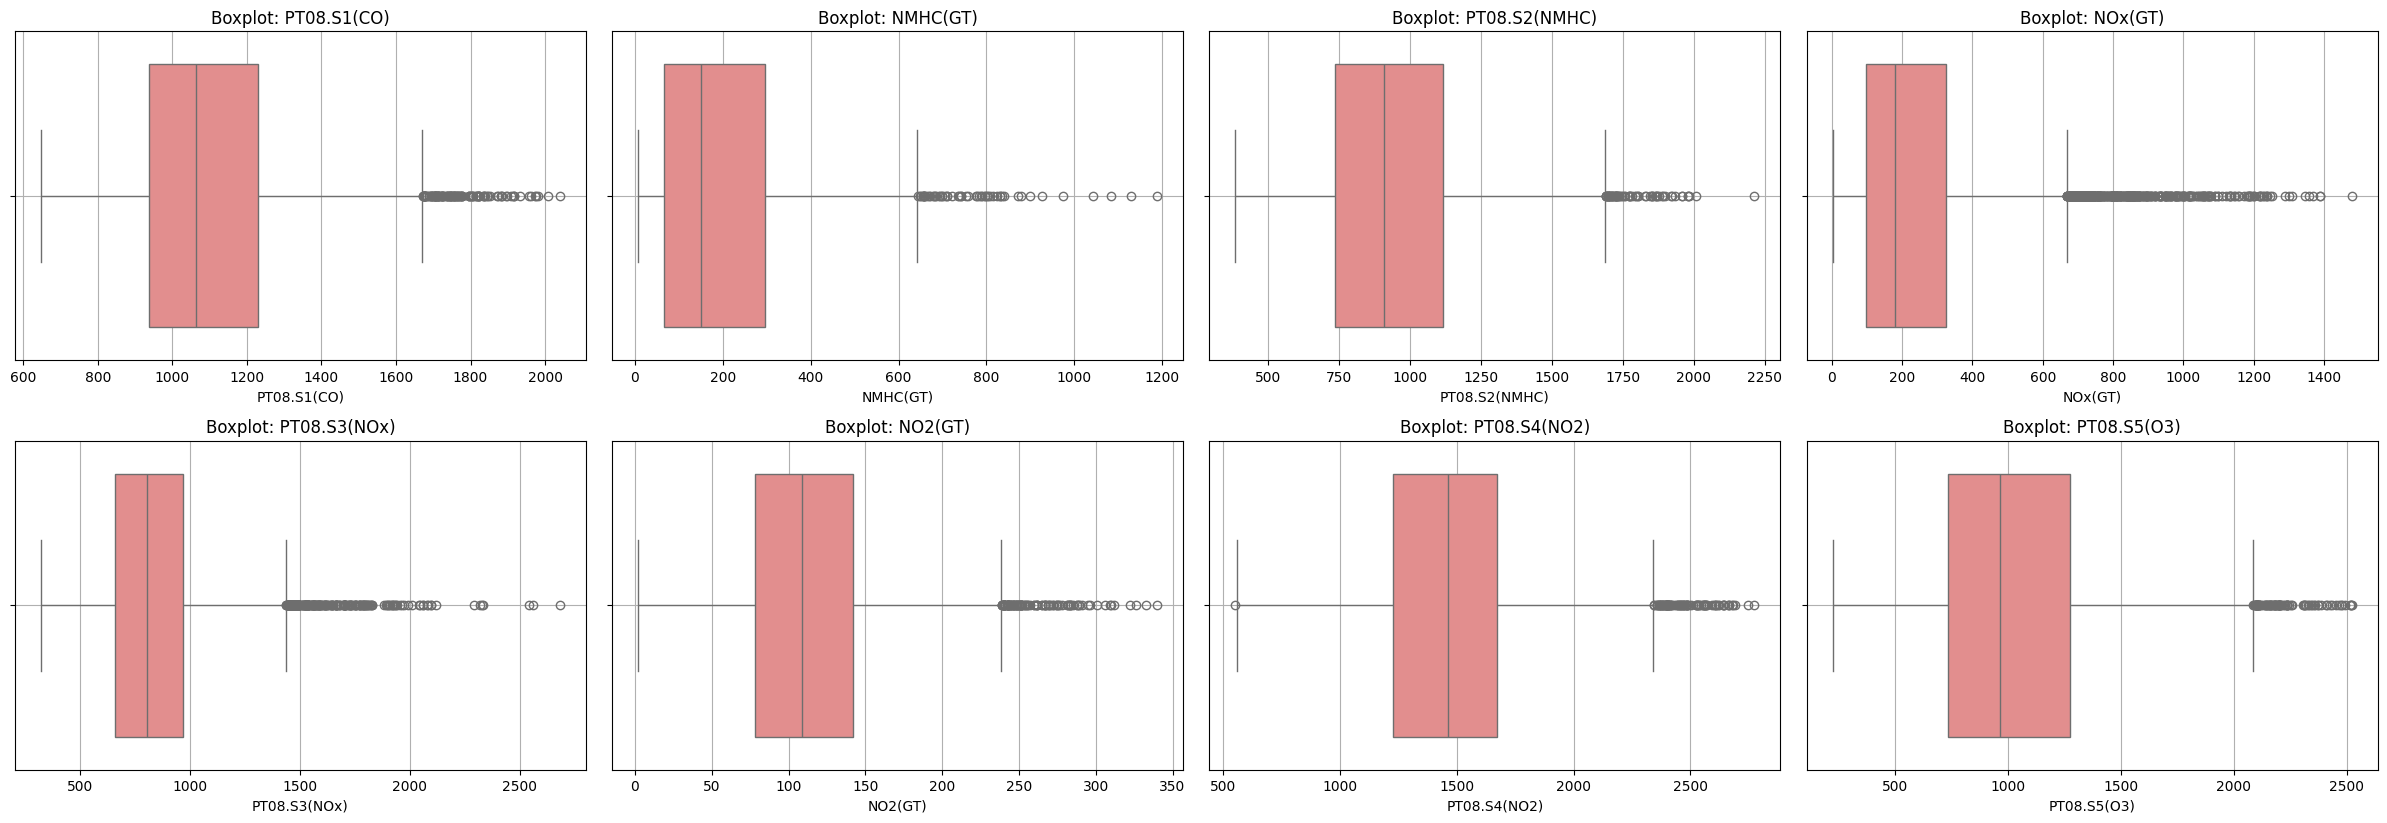

In [10]:
cols = 4
rows = math.ceil(len(float64_cols) / cols)

plt.figure(figsize=(6 * cols, 4 * rows))

for i, col in enumerate(float64_cols):
    # Clean the column
    clean_col = df[col].replace(-200, pd.NA).dropna()
    
    # Skip if empty after cleaning
    if clean_col.empty:
        continue
    
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(x=clean_col, color='lightcoral')
    plt.title(f'Boxplot: {col}')
    plt.grid(True)

plt.tight_layout()
plt.show()

U sledećem box-u možemo da prikažemo promenu naših promenljivih kroz vreme, tj. po indeksima jer još uvek nismo spojili naše kolone u datetime kolonu (to ćemo uraditi u EDA delu). Ovako možemo pratiti kako otprilike izgleda promena naših numeričkih kolona.

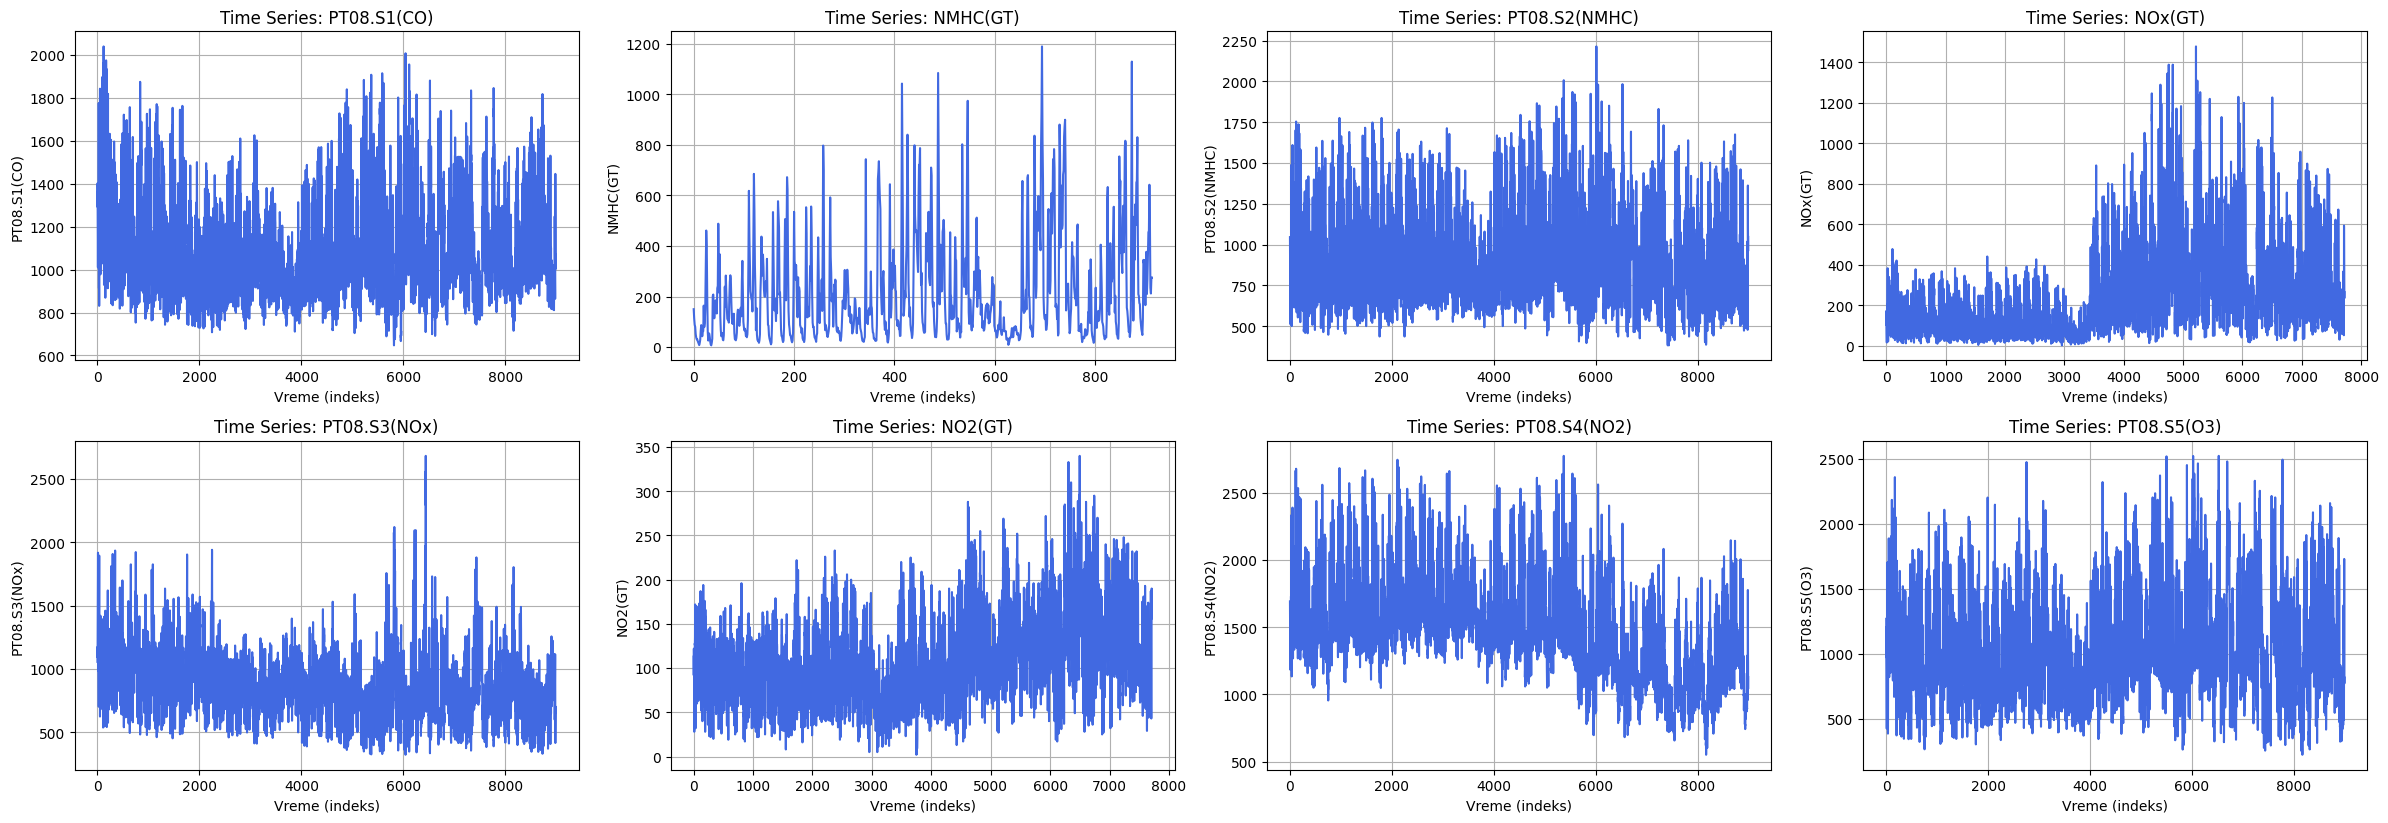

In [11]:
rows = math.ceil(len(float64_cols) / cols)
plt.figure(figsize=(6 * cols, 4 * rows))

for i, col in enumerate(float64_cols):
    # Clean the column: replace -200 with NaN and drop missing values
    clean_col = df[col].replace(-200, np.nan).dropna()
    if clean_col.empty:
        continue

    plt.subplot(rows, cols, i + 1)
    plt.plot(clean_col.values, color='royalblue')
    plt.title(f'Time Series: {col}')
    plt.xlabel('Vreme (indeks)')
    plt.ylabel(col)
    plt.grid(True)

plt.tight_layout()
plt.show()

Vidimo da je bilo nekih odskakanja u PT08.S3(NOx), i da je recimo NMHC(GT) jako drugačija kroz vreme, tj. da ima odskakanja. dok su sve ostale poprilično stabilne osim recimo NOx(GT) jer ona je imala malo blaži početak i u nekom trenutku je krenula da raste.

Sada ćemo napraviti scatter plot, on je sličan našem plotu koji ide kroz vreme. Možda ima malo detaljinij prikaz kada se odstupanja jasnije vide.

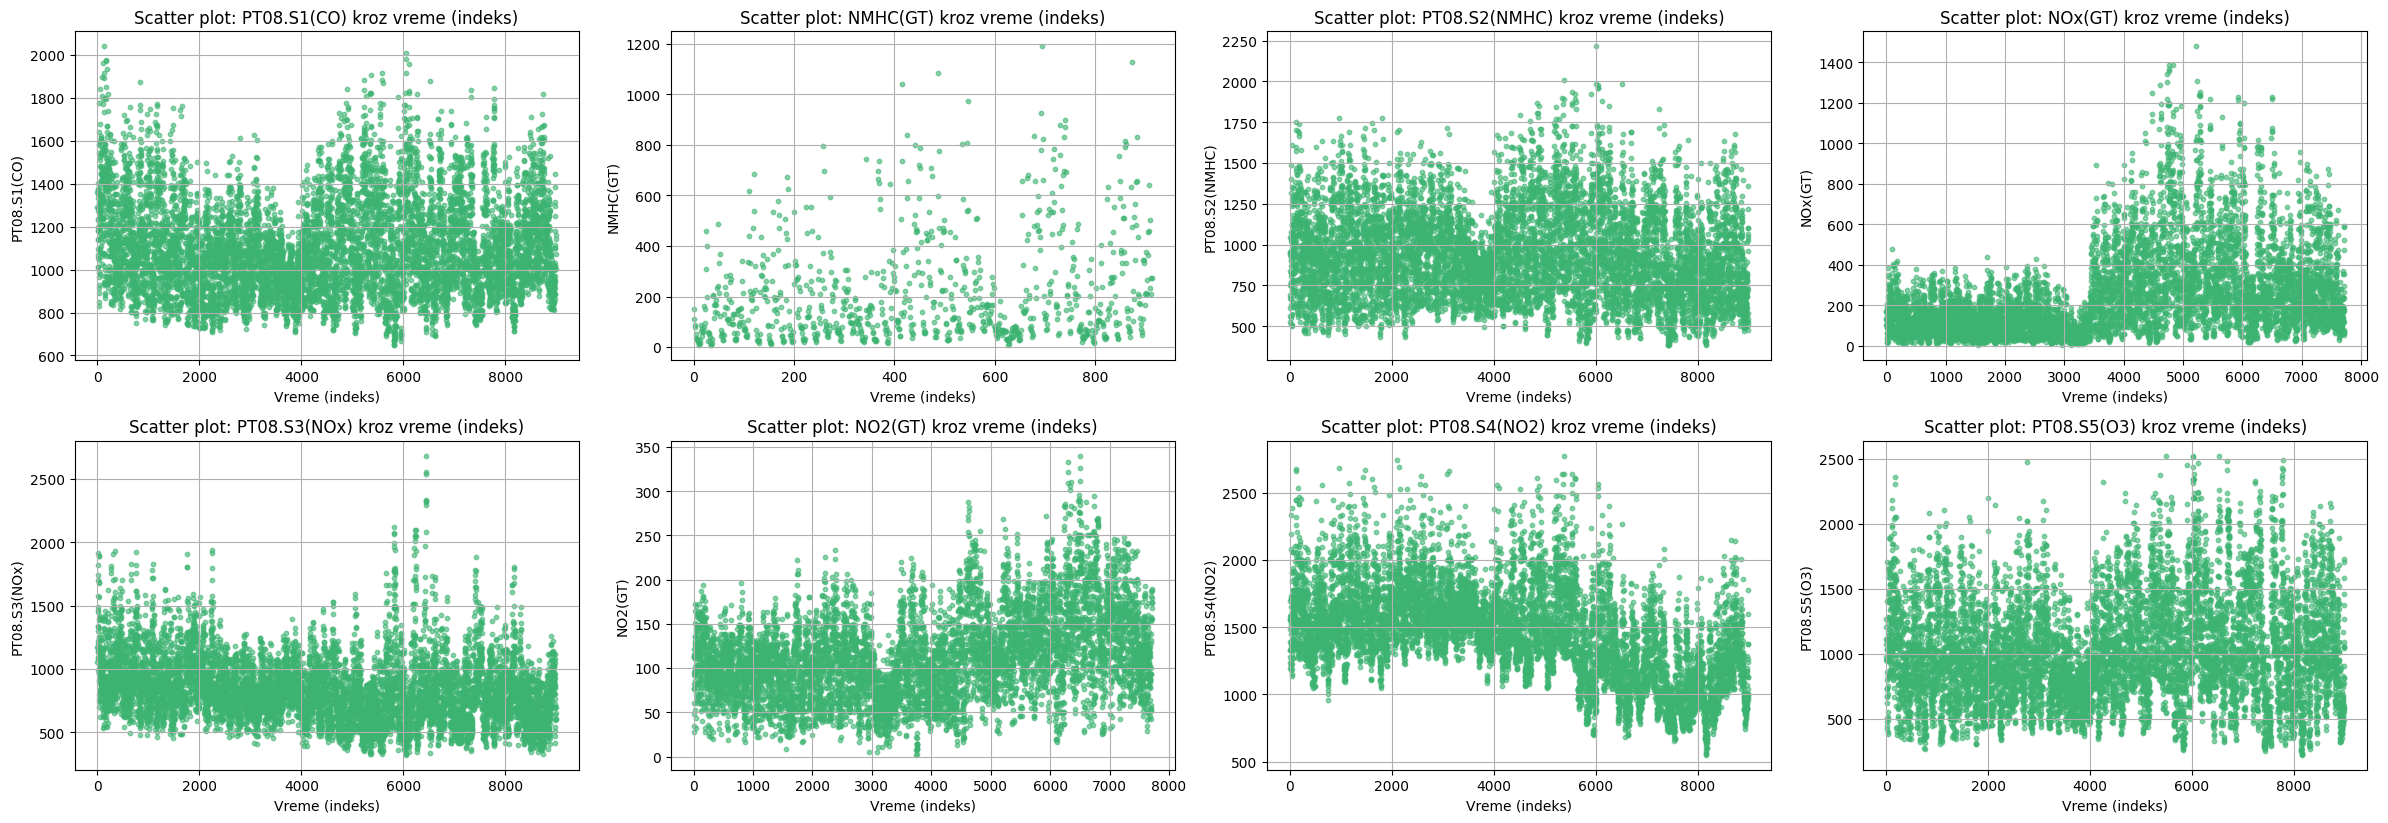

In [12]:
rows = math.ceil(len(float64_cols) / cols)
plt.figure(figsize=(6 * cols, 4 * rows))

for i, col in enumerate(float64_cols):
    clean_col = df[col].replace(-200, np.nan).dropna()
    if clean_col.empty:
        continue

    plt.subplot(rows, cols, i + 1)
    plt.scatter(range(len(clean_col)), clean_col, c='mediumseagreen', alpha=0.6, s=10)
    plt.title(f'Scatter plot: {col} kroz vreme (indeks)')
    plt.xlabel('Vreme (indeks)')
    plt.ylabel(col)
    plt.grid(True)

plt.tight_layout()
plt.show()

Sada možemo naslikati matricu korelacije. Korelacija služi da mi vidimo u kakvom su odnosu naše kolone, tj. možemo da vidimo šta od čega zavisi u našem dataset-u.

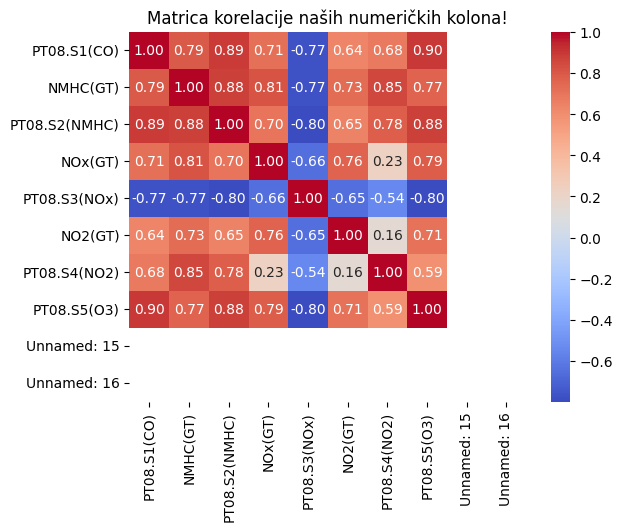

In [13]:
sns.heatmap(df[float64_cols].replace(-200, np.nan).corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matrica korelacije naših numeričkih kolona!')
plt.show()

Odavde možemo da zaključimo da su naše kolone Unnamed: 15 i 16, nepotrebne, te ćemo iste obrisati kasnije u EDA delu. 
Takodje raspodela je sledeća:
1) Ako je korelacija veća od 0.5, onda kažemo da su u jakoj pozitivnoj korelaciji
2) Ako je izmedju 0.3 i 0.49, onda kažemo da su u okej pozitivnoj korelaciji
3) AKo je izmedju 0.1 i 0.29, onda su u baš slaboj pozitivnoj korelaciji.
4) Isto važi i za negativne, samo su oni u negativnoj korelaciji.

Razlika izmedju negativne i pozitivne korelacije: 
- U pozitivnoj korelaciji što su kolone u većoj korelaciji to zavise više jedna od druge tj. kako jedna raste i druga raste ili kako jedna opada i druga opada
- U negativnoj je totalno suprotno, kako jedna raste tako druga opada ili kako jedna opada druga raste.


# Priprema podatak i istraživačka analiza (Faza 3)

- Prva stavka koju ćemo odraditi je provera nedostajućih vrednosti, konverzija podataka koji nisu dobri i čišćenje nepotrebnih kolona koje smo videli u prethodnom delu.

In [14]:
df = df.drop(columns=['Unnamed: 15', 'Unnamed: 16'])

In [15]:
df.head(5)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578"
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255"
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502"
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867"
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888"


- Konkretno u ovom koraku smo obrisali kolone 'Unnamed: 15' i 'Unnamed: 16' jer su nepotrebno, tj. sve su NaN vrednosti
- Sledeći korak će biti konverzija podataka koji su object: CO(GT), C6H6(GT), T, RH, AH - ove kolone imaju , umesto . kao decimalni razmak

In [17]:
cols = ['CO(GT)', 'C6H6(GT)', 'T', 'RH', 'AH'] # kolone koje su object tipa, a treba da budu float
df[cols] = df[cols].apply(lambda x: float(str(x).replace(',', '.')) if isinstance(x, str) else x)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   float64
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   float64
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   float64
 13  RH             9357 non-null   float64
 14  AH             9357 non-null   float64
dtypes: float64(13), object(2)
memory usage: 1.1+ MB


- Sada vidimo da smo pravilno konvertovali kolone u odgovarajući float64 format.
- Sledeći korak je da pretvorimo kolone Date i Time u Datetime format.

In [22]:
df['DateTime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S')
df.insert(0, 'DateTime', df.pop('DateTime'))  # premeštamo DateTime na početak

In [23]:
df.head(2)

,DateTime,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10 18:00:00,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2004-03-10 19:00:00,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255


- Sledeći korak može biti uklanjanje Date i Time kolona.
- Takodje ćemo da zamenimo -200 vrednosti sa NaN vrednostima, kako bi lakše manipulisali istim.

In [24]:
df = df.drop(columns=['Date', 'Time'])

In [25]:
df = df.replace(-200, np.nan)

In [ ]:
(df.isna().sum() / len(df)) * 100 # prikazujemo procenat NaN vrednosti po kolonama

DateTime          1.203674
CO(GT)           18.973709
PT08.S1(CO)       5.068103
NMHC(GT)         90.349488
C6H6(GT)          5.068103
PT08.S2(NMHC)     5.068103
NOx(GT)          18.509133
PT08.S3(NOx)      5.068103
NO2(GT)          18.540809
PT08.S4(NO2)      5.068103
PT08.S5(O3)       5.068103
T                 5.068103
RH                5.068103
AH                5.068103
dtype: float64

### Zaključci:
- Vidimo da sve vrednosti osim NMHC(GT) imaju normalan broj nedostajućih vrednosti
- Kolona NMHC(GT) ima 90.3% nedostajućih vrednosti, što znači da možemo da je obrišemo
- Ako bi je eventualno imputovali, to ne bi bilo dobro po kasnije stavke ovog projekta, tj. treniranje modela

In [28]:
df = df.drop(columns=['NMHC(GT)'])

In [29]:
df.head(2)

,DateTime,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10 18:00:00,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,2004-03-10 19:00:00,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255


- Takodje s obzirom da nam DateTime kolona ima NaN vrednosti, i da nju nije moguće Impute-ovati (dopuniti pomoću nekog od Imputer-a nedostajuće vrednosti), najbolje bi bilo da obrišemo te kolone
- Svakako je procenat istih ~1.2% tako da neće mnogo uticati na naš dataset

In [33]:
df = df.dropna(subset=['DateTime'])

- Hajde da proverimo ima li duplikata u našem dataset-u

In [34]:
(df.duplicated() == True).sum()

np.int64(0)

- Vidimo da nemamo duplikate u našem dataset-u

### Korelacije
- Hajde da ponovo vidimo heatmap, sada kada smo pročistili naš dataset.

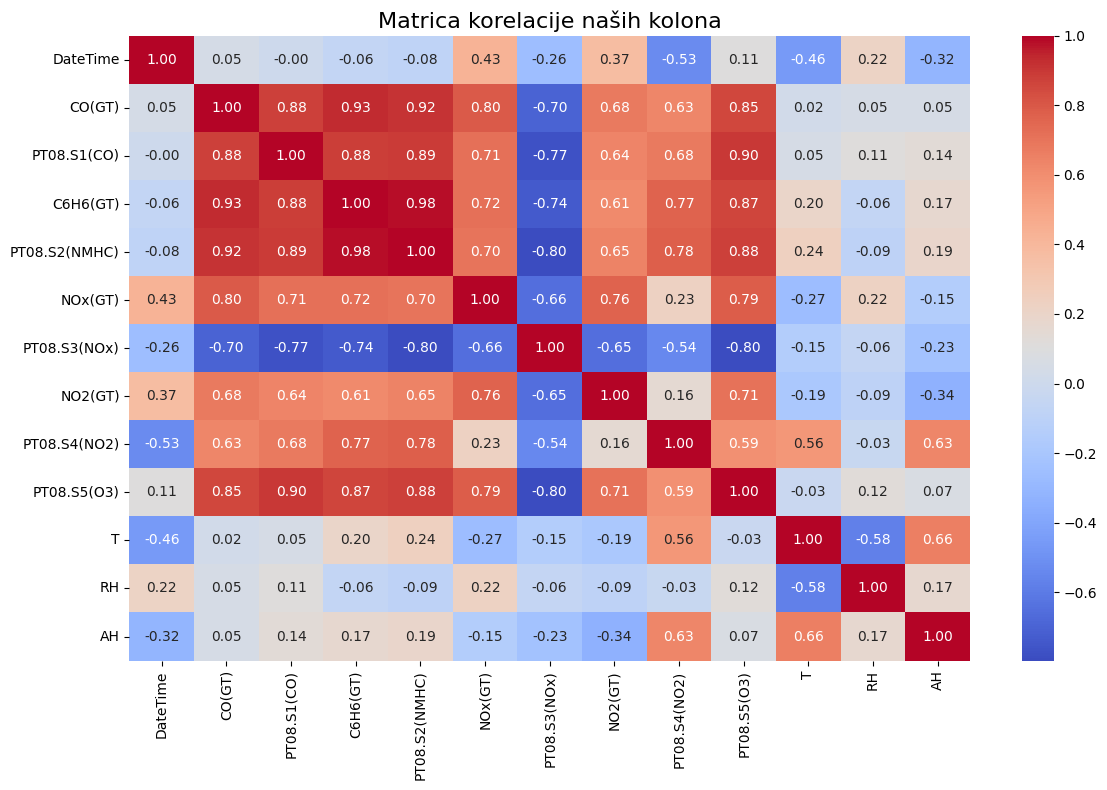

In [ ]:
plt.figure(figsize=(12, 8)) 
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Matrica korelacije naših kolona', fontsize=16)
plt.tight_layout()
plt.show()

- Sada možemo precizno videti korelacije u našem dataset-u
- Pravila su ista kao i prethodno opisana u gornjem delu notebook-a

### Uklanjanje nedostajućih NaN vrednosti
- Za ovo će nam biti potreban Imputer
- Za kolone koje imaju mali broj NaN do ~6% ćemo koristiti SimpleImputer
- Za kolone koje imaju veći broj NaN vrednosti do ~20% ćemo korisiti KNNImputer
--------------------------
- CO(GT)           18.973709
- PT08.S1(CO)       5.068103 
- C6H6(GT)          5.068103 
- PT08.S2(NMHC)     5.068103 
- NOx(GT)          18.509133
- PT08.S3(NOx)      5.068103 
- NO2(GT)          18.540809
- PT08.S4(NO2)      5.068103 
- PT08.S5(O3)       5.068103
- T                 5.068103
- RH                5.068103
- AH                5.068103

In [35]:
from sklearn.impute import KNNImputer, SimpleImputer

In [40]:
knn_feautres = ['CO(GT)', 'NOx(GT)', 'NO2(GT)']
simple_features = ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'C6H6(GT)', 'T', 'RH', 'AH']

In [ ]:
simpleImputer = SimpleImputer(strategy='mean')
knnImputer = KNNImputer(n_neighbors=8) # ovo smo postavili na 8, kako bi imali pristup većem broju susednih vrednosti

In [42]:
df[knn_feautres] = knnImputer.fit_transform(df[knn_feautres])
df[simple_features] = simpleImputer.fit_transform(df[simple_features])

In [43]:
df.isna().sum()

DateTime         0
CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

#### Zaključci:
- Imputovanjem smo se otarasili NaN vrednosti koje bi nam smetale u kasnijem procesiranju
- Za kolone koje imaju ~18% nedostajućih vrednosti smo koristili KNNImputer, kako bi imali pristup nekom broju susednih vrednost i kako bi što preciznije popunili te podatke
- Za kolone koje su bile na ~5% smo koristili SimpleImputer, sa strategijom mean koja funkcioniše tako što na osnovu mean-a popunjava nedostajuće vrednosti u našim kolonama koje smo izabrali
- Takodje će nam usled velikih razlika u vrednostima biti potreban Scaler, kako bi mogli da ujednačimo naše vrednosti, tj. opseg naših vrednosti jer npr:
    - CO(GT) ima opseg od 0-10
    - PT08.S1(CO) ima opseg od 500-2000
    - ...
- Tako da bi smo mogli da koristimo ili StandardScaler ili MinMaxScaler
- Mi ćemo ovde koristiti StandardScaler, zato što iz faze 2 mi možemo da zaključimo da naše kolone imaju normalnu distribuciju
- Takodje ćemo sačuvati DateTime kolonu kako bi je koristili kasnije za vremenske serije (time series)

In [44]:
from sklearn.preprocessing import StandardScaler

standardScaler = StandardScaler()
dt_col = df['DateTime']
df = df.drop(columns=['DateTime'])
df[df.columns] = standardScaler.fit_transform(df[df.columns])
df.insert(0, 'DateTime', dt_col)

In [46]:
df.head(5)

,DateTime,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10 18:00:00,0.365862,1.222702,0.248813,0.408519,-0.390711,0.875962,0.053392,0.694669,0.627494,-0.544962,-0.019689,-0.676404
1,2004-03-10 19:00:00,-0.082483,0.903123,-0.093547,0.060588,-0.712396,1.344717,-0.415912,0.302742,-0.130331,-0.579615,-0.090386,-0.758008
2,2004-03-10 20:00:00,0.066965,1.420088,-0.148325,-0.000586,-0.569425,1.209652,0.075740,0.290955,0.130812,-0.741330,0.280772,-0.695605
3,2004-03-10 21:00:00,0.066965,1.297897,-0.120936,0.033824,-0.360074,1.018972,0.254523,0.376413,0.461080,-0.845290,0.634256,-0.603390
4,2004-03-10 22:00:00,-0.381380,0.809130,-0.490684,-0.394398,-0.569425,1.467865,0.120436,0.099412,0.222979,-0.822188,0.610691,-0.598084
